# eBay Perfume E-Commerce Market Analysis

**Track:** Track 2 - GitHub Data Analysis Project  
**Dataset:** Kaggle Perfume E-Commerce Dataset  
**Source:** https://www.kaggle.com/datasets/aminasalamt/perfume-e-commerce-dataset/data  
**Access date:** April 2026

## Project Objective

This project analyses eBay perfume listings to compare pricing patterns, demand signals, brand presence, and product opportunities.

**Target users:** small e-commerce sellers, marketing students, and business analysts interested in online perfume market trends.

**Business question:** Which perfume segments, brands, and price ranges show stronger market potential on eBay?


## 1. Import Libraries

Load the packages used for data cleaning, analysis, and visualisation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)


## 2. Load Data

Read the men’s and women’s perfume datasets and combine them for analysis.


In [2]:
data_dir = Path(".")

women_file = data_dir / "ebay_womens_perfume.csv"
men_file = data_dir / "ebay_mens_perfume.csv"

if not women_file.exists() or not men_file.exists():
    data_dir = Path("data")
    women_file = data_dir / "ebay_womens_perfume.csv"
    men_file = data_dir / "ebay_mens_perfume.csv"

women = pd.read_csv(women_file)
men = pd.read_csv(men_file)

# Add segment labels before merging.
women["gender_segment"] = "Women"
men["gender_segment"] = "Men"

raw = pd.concat([women, men], ignore_index=True)
raw.head()


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,gender_segment
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,US $43.99/ea,2.00,2 available / 393 sold,393.00,"May 23, 2024 10:43:50 PDT","Thomasville, Alabama, United States",Women
1,As Shown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.00,5 available / 40 sold,40.00,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong",Women
2,PRADA,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,10.00,More than 10 available / 35 sold,35.00,"May 14, 2024 20:54:25 PDT","Orange, New Jersey, United States",Women
3,As Show,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.00,More than 10 available / 9 sold,9.00,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong",Women
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.00,More than 10 available,NaN,NaN,"Little Ferry, New Jersey, United States",Women


In [3]:
# Basic dataset overview.
dataset_overview = pd.DataFrame({
    "metric": ["rows", "columns", "women_rows", "men_rows"],
    "value": [raw.shape[0], raw.shape[1], len(women), len(men)]
})

dataset_overview


,metric,value
0,rows,2000
1,columns,11
2,women_rows,1000
3,men_rows,1000


## 3. Data Quality Check

Check column types, missing values, and duplicated product titles before cleaning.


In [4]:
# Check column types and missing values.
quality_check = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_values": raw.isna().sum(),
    "missing_percent": raw.isna().mean() * 100,
    "unique_values": raw.nunique()
}).sort_values("missing_values", ascending=False)

quality_check


,dtype,missing_values,missing_percent,unique_values
available,float64,242,12.10,145
lastUpdated,object,126,6.30,1831
sold,float64,22,1.10,670
availableText,object,11,0.55,1300
type,object,5,0.25,116
brand,object,2,0.10,401
title,object,0,0.00,1941
price,float64,0,0.00,1004
priceWithCurrency,object,0,0.00,1164
itemLocation,object,0,0.00,447


In [5]:
# Check duplicated product titles.
duplicate_summary = pd.DataFrame({
    "metric": ["duplicate_titles", "unique_brands", "unique_types"],
    "value": [
        raw["title"].duplicated().sum(),
        raw["brand"].nunique(),
        raw["type"].nunique()
    ]
})

duplicate_summary


,metric,value
0,duplicate_titles,59
1,unique_brands,401
2,unique_types,116


## 4. Data Cleaning and Preparation

Clean text fields, handle missing values, and keep valid numeric records.


In [6]:
df = raw.copy()

# Clean text fields.
df["brand"] = df["brand"].fillna("Unknown").astype(str).str.strip()
df["type"] = df["type"].fillna("Unknown").astype(str).str.strip()
df["title"] = df["title"].fillna("Unknown").astype(str).str.strip()
df["itemLocation"] = df["itemLocation"].fillna("Unknown").astype(str).str.strip()

# Clean numeric fields.
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["available"] = pd.to_numeric(df["available"], errors="coerce").fillna(0)
df["sold"] = pd.to_numeric(df["sold"], errors="coerce").fillna(0)

# Keep valid observations.
df = df[(df["price"] > 0) & (df["sold"] >= 0)].copy()

# Remove extreme price outliers for clearer analysis.
price_cap = df["price"].quantile(0.99)
df = df[df["price"] <= price_cap].copy()

df.head()


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,gender_segment
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,US $43.99/ea,2.00,2 available / 393 sold,393.00,"May 23, 2024 10:43:50 PDT","Thomasville, Alabama, United States",Women
1,As Shown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.00,5 available / 40 sold,40.00,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong",Women
2,PRADA,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,10.00,More than 10 available / 35 sold,35.00,"May 14, 2024 20:54:25 PDT","Orange, New Jersey, United States",Women
3,As Show,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.00,More than 10 available / 9 sold,9.00,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong",Women
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.00,More than 10 available,0.00,NaN,"Little Ferry, New Jersey, United States",Women


In [7]:
# Cleaning summary.
cleaning_summary = pd.DataFrame({
    "metric": ["original_rows", "cleaned_rows", "removed_rows", "price_cap_99th_percentile"],
    "value": [len(raw), len(df), len(raw) - len(df), round(price_cap, 2)]
})

cleaning_summary


,metric,value
0,original_rows,"2,000.00"
1,cleaned_rows,"1,980.00"
2,removed_rows,20.00
3,price_cap_99th_percentile,166.21


## 5. Feature Engineering

Create business analysis fields for price segmentation, location, and demand proxy.


In [8]:
# Standardise labels.
df["brand_clean"] = (
    df["brand"]
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
    .replace({"As Show": "As Shown"})
)

df["type_clean"] = (
    df["type"]
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("Eau De", "Eau de", regex=False)
    .str.replace("Eau de Perfume", "Eau de Parfum", regex=False)
    .str.strip()
)

# Create analysis fields.
df["sales_proxy"] = df["price"] * df["sold"]

df["price_segment"] = pd.cut(
    df["price"],
    bins=[0, 25, 50, 100, np.inf],
    labels=["Budget (<$25)", "Mid-range ($25-$50)", "Premium ($50-$100)", "Luxury ($100+)"]
)

df["location_country"] = df["itemLocation"].str.split(",").str[-1].str.strip()
df["has_sales_signal"] = df["sold"] > 0

df[["gender_segment", "brand_clean", "type_clean", "price", "sold", "sales_proxy", "price_segment"]].head()


,gender_segment,brand_clean,type_clean,price,sold,sales_proxy,price_segment
0,Women,Carolina Herrera,Eau de Parfum,43.99,393.00,"17,288.07",Mid-range ($25-$50)
1,Women,As Shown,Eau de Parfum,79.99,40.00,"3,199.60",Premium ($50-$100)
2,Women,Prada,Eau de Parfum,59.99,35.00,"2,099.65",Premium ($50-$100)
3,Women,As Shown,Eau de Parfum,59.99,9.00,539.91,Premium ($50-$100)
4,Women,Khadlaj,Eau de Parfum,29.99,0.00,0.00,Mid-range ($25-$50)


## 6. Market Profile

Summarise listings, prices, sold quantity, and sales proxy by gender segment.


In [9]:
market_profile = df.groupby("gender_segment").agg(
    listings=("title", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    total_units_sold=("sold", "sum"),
    avg_units_sold=("sold", "mean"),
    sales_proxy=("sales_proxy", "sum")
).sort_values("sales_proxy", ascending=False)

market_profile


,listings,avg_price,median_price,total_units_sold,avg_units_sold,sales_proxy
gender_segment,,,,,,
Men,985,44.15,34.99,"760,344.00",771.92,"25,528,657.48"
Women,995,38.78,32.95,"489,190.00",491.65,"13,839,646.04"


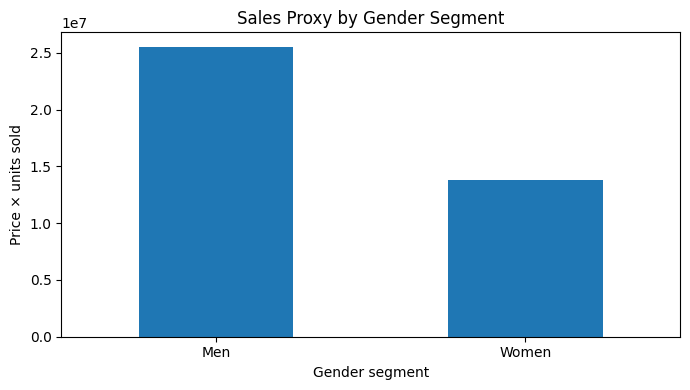

In [10]:
# Plot sales proxy by gender segment.
ax = market_profile["sales_proxy"].plot(kind="bar", figsize=(7, 4))
ax.set_title("Sales Proxy by Gender Segment")
ax.set_xlabel("Gender segment")
ax.set_ylabel("Price × units sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Brand Analysis

Compare brands by listing volume, average price, sold quantity, and sales proxy.


In [11]:
brand_summary = df.groupby("brand_clean").agg(
    listings=("title", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    total_units_sold=("sold", "sum"),
    avg_units_sold=("sold", "mean"),
    sales_proxy=("sales_proxy", "sum")
).query("listings >= 5").sort_values("sales_proxy", ascending=False)

brand_summary.head(10)


,listings,avg_price,median_price,total_units_sold,avg_units_sold,sales_proxy
brand_clean,,,,,,
Versace,53,36.89,37.63,"128,077.00","2,416.55","4,462,322.28"
Calvin Klein,34,24.87,24.80,"145,672.00","4,284.47","3,767,046.48"
Davidoff,11,24.42,24.49,"60,289.00","5,480.82","1,682,640.80"
Azzaro,15,42.80,26.97,"38,305.00","2,553.67","1,673,078.61"
Burberry,34,39.67,33.53,"38,361.00","1,128.26","1,227,084.05"
Dolce & Gabbana,23,39.27,43.32,"28,570.00","1,242.17","1,090,757.30"
Paco Rabanne,47,59.40,49.99,"23,506.00",500.13,"1,071,818.83"
Yves Saint Laurent,54,56.77,54.49,"13,818.00",255.89,"981,944.86"
Armaf,42,39.59,33.42,"27,120.00",645.71,"967,786.79"


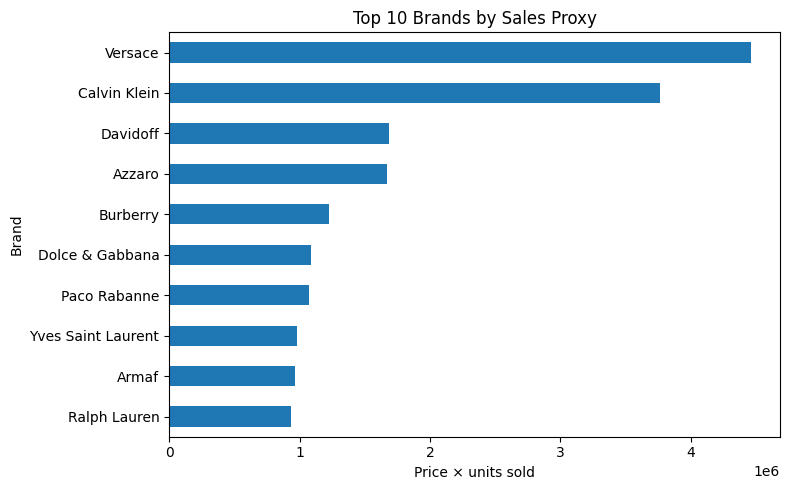

In [12]:
# Plot top brands by sales proxy.
top_brands = brand_summary.head(10).sort_values("sales_proxy")

ax = top_brands["sales_proxy"].plot(kind="barh", figsize=(8, 5))
ax.set_title("Top 10 Brands by Sales Proxy")
ax.set_xlabel("Price × units sold")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()


## 8. Price Segment Analysis

Use price bands to compare product distribution and demand signal.


In [13]:
price_summary = df.groupby("price_segment", observed=False).agg(
    listings=("title", "count"),
    avg_price=("price", "mean"),
    total_units_sold=("sold", "sum"),
    avg_units_sold=("sold", "mean"),
    sales_proxy=("sales_proxy", "sum")
)

price_summary


,listings,avg_price,total_units_sold,avg_units_sold,sales_proxy
price_segment,,,,,
Budget (<$25),625,17.01,"483,274.00",773.24,"8,726,309.64"
Mid-range ($25-$50),835,36.50,"632,322.00",757.27,"21,655,534.99"
Premium ($50-$100),441,70.55,"127,750.00",289.68,"8,207,800.73"
Luxury ($100+),79,124.72,"6,188.00",78.33,"778,658.16"


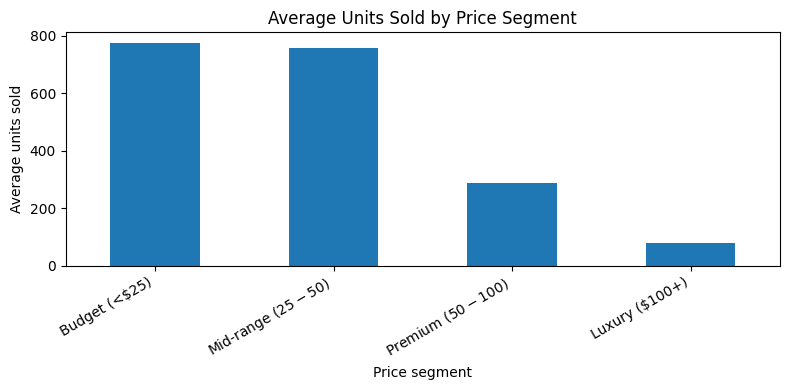

In [14]:
# Plot average units sold by price segment.
ax = price_summary["avg_units_sold"].plot(kind="bar", figsize=(8, 4))
ax.set_title("Average Units Sold by Price Segment")
ax.set_xlabel("Price segment")
ax.set_ylabel("Average units sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 9. Product Type Analysis

Group products by perfume type to compare product-level performance.


In [15]:
type_summary = df.groupby("type_clean").agg(
    listings=("title", "count"),
    avg_price=("price", "mean"),
    total_units_sold=("sold", "sum"),
    avg_units_sold=("sold", "mean"),
    sales_proxy=("sales_proxy", "sum")
).query("listings >= 10").sort_values("sales_proxy", ascending=False)

type_summary.head(10)


,listings,avg_price,total_units_sold,avg_units_sold,sales_proxy
type_clean,,,,,
Eau de Toilette,643,38.01,"735,887.00","1,144.46","24,083,767.61"
Eau de Parfum,895,45.68,"295,153.00",329.78,"10,296,050.36"
Eau de Cologne,95,41.76,"51,599.00",543.15,"1,030,242.59"
Perfume,105,34.73,"15,980.00",152.19,"313,338.15"
Parfum,16,58.56,"1,896.00",118.50,"125,431.66"
Fragrances,46,35.28,"1,124.00",24.43,"41,262.80"
Fragrance Mist,11,21.44,783.00,71.18,"11,723.77"


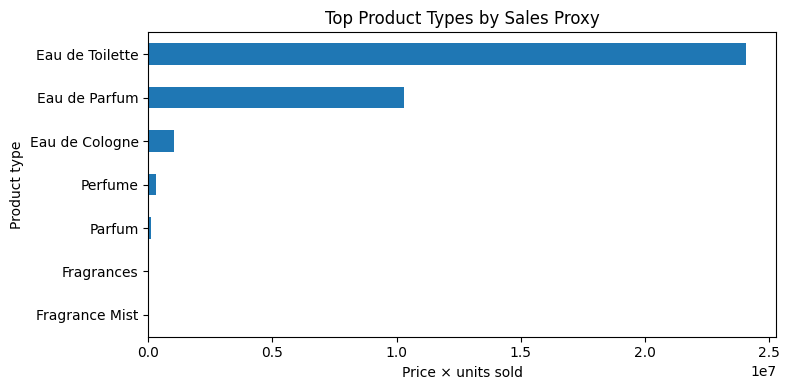

In [16]:
# Plot top product types by sales proxy.
top_types = type_summary.head(8).sort_values("sales_proxy")

ax = top_types["sales_proxy"].plot(kind="barh", figsize=(8, 4))
ax.set_title("Top Product Types by Sales Proxy")
ax.set_xlabel("Price × units sold")
ax.set_ylabel("Product type")
plt.tight_layout()
plt.show()


## 10. Price and Demand Signal

Compare price with sold quantity and calculate simple correlations.


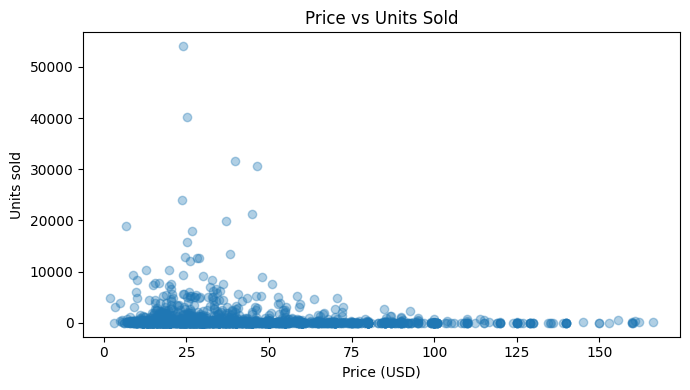

,price,sold,available,sales_proxy
count,"1,980.00","1,980.00","1,980.00","1,980.00"
mean,41.45,631.08,18.36,"19,882.98"
std,27.50,"2,469.04",53.91,"77,212.84"
min,1.99,0.00,0.00,0.00
25%,21.94,14.00,3.00,500.00
50%,33.97,50.00,9.00,"1,799.47"
75%,52.83,280.75,10.00,"9,402.36"
max,166.18,"54,052.00",842.00,"1,420,246.15"


In [17]:
# Limit the plot range for readability.
plot_df = df[df["price"] <= 200].copy()

plt.figure(figsize=(7, 4))
plt.scatter(plot_df["price"], plot_df["sold"], alpha=0.35)
plt.title("Price vs Units Sold")
plt.xlabel("Price (USD)")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

numeric_summary = df[["price", "sold", "available", "sales_proxy"]].describe()
numeric_summary


In [18]:
# Correlation between core numeric fields.
correlation = df[["price", "sold", "available", "sales_proxy"]].corr()
correlation


,price,sold,available,sales_proxy
price,1.00,-0.09,-0.12,-0.01
sold,-0.09,1.00,0.12,0.93
available,-0.12,0.12,1.00,0.09
sales_proxy,-0.01,0.93,0.09,1.00


## 11. Product Opportunity Shortlist

Filter products with moderate prices and stronger sold-quantity signals.


In [19]:
median_price = df["price"].median()
median_sold = df["sold"].median()

# Select products with moderate price and above-median sold quantity.
opportunities = (
    df[(df["price"] <= median_price) & (df["sold"] > median_sold)]
    .sort_values(["sold", "sales_proxy"], ascending=False)
    [["gender_segment", "brand_clean", "title", "type_clean", "price", "sold", "sales_proxy", "price_segment"]]
    .head(10)
)

opportunities


,gender_segment,brand_clean,title,type_clean,price,sold,sales_proxy,price_segment
1081,Men,Calvin Klein,Ck One by Calvin Klein Cologne Perfume Unisex ...,Unknown,23.89,"54,052.00","1,291,302.28",Budget (<$25)
1642,Men,Davidoff,Cool Water by Davidoff 4.2 oz EDT Cologne for ...,Eau de Toilette,25.23,"40,130.00","1,012,479.90",Mid-range ($25-$50)
1076,Men,Calvin Klein,OBSESSION by Calvin Klein 4.0 oz 4 MEN edt Col...,Eau de Toilette,23.56,"24,048.00","566,570.88",Budget (<$25)
1061,Men,2Nd To None,6 For $19.95 MEN(M) WOMEN(W) & UNISEX(U) Body ...,Concentrated Uncut Pure Body Oil,6.65,"18,882.00","125,565.30",Budget (<$25)
345,Women,Calvin Klein,Escape by Calvin Klein EDP Perfume for Women 3...,Eau de Parfum,26.66,"17,854.00","475,987.64",Mid-range ($25-$50)
359,Women,Vera Wang,VERA WANG Perfume 3.3 / 3.4 oz EDP For Women S...,Eau de Parfume,25.25,"15,897.00","401,399.25",Mid-range ($25-$50)
1058,Men,Kenneth Cole,KENNETH COLE BLACK Cologne for Men 3.4 oz EDT ...,Eau de Toilette,24.70,"12,865.00","317,765.50",Budget (<$25)
1049,Men,C.K,Eternity by Calvin Klein 3.4 oz EDT Cologne fo...,Eau de Toilette,28.75,"12,739.00","366,246.25",Mid-range ($25-$50)
1284,Men,Burberry,Burberry Touch by Burberry EDT Cologne for Men...,Eau de Toilette,28.25,"12,583.00","355,469.75",Mid-range ($25-$50)
1059,Men,Tommy Hilfiger,TOMMY BOY EST 1985 by Tommy Hilfiger Cologne e...,Eau de Toilette,26.11,"12,184.00","318,124.24",Mid-range ($25-$50)


## 12. Export Results

Save cleaned data and summary tables for reproducibility and GitHub submission.


In [20]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Export cleaned data and summary tables.
df.to_csv(output_dir / "cleaned_perfume_market_data.csv", index=False)
market_profile.to_csv(output_dir / "market_profile.csv")
brand_summary.to_csv(output_dir / "brand_summary.csv")
price_summary.to_csv(output_dir / "price_segment_summary.csv")
type_summary.to_csv(output_dir / "type_summary.csv")
opportunities.to_csv(output_dir / "product_opportunity_shortlist.csv", index=False)

print("Export completed.")


Export completed.


## Notebook Checklist

This notebook includes:

- problem definition and target users
- data source and access date
- data loading
- data quality check
- data cleaning and preparation
- feature engineering
- descriptive analysis
- visual outputs
- exported results
